# Deep Learning for 4-Class Motor Imagery Decoding

## 1. Objective

The goal of this module is to develop and evaluate an EEGNet-based neural decoder for four motor-imagery tasks: **left hand, right hand, feet, and tongue**, using EEG recordings from the BCI Competition IV 2a dataset.

The primary evaluation is **cross-subject**: train, validation, and test sets are separated by participant, so no EEG epoch from a test participant is used during model fitting, early stopping, or hyperparameter selection. This protocol estimates how well the decoder transfers to participants not represented during development.

Four-class decoding is more challenging than binary motor-imagery decoding because the neural signatures can overlap spatially and temporally, particularly for hand and foot imagery.

## 2. Pipeline features

* **Subject-wise train/validation/test split:** participants, rather than trials, define the splits. Hyperparameters are selected using validation participants only; final metrics are computed once on held-out test participants.
* **Explicit event mapping:** event IDs are passed explicitly to MNE (`left=1`, `right=2`, `feet=3`, `tongue=4`). This prevents an unintended alphabetical mapping of annotation labels to numeric IDs.
* **EEGNet architecture:** a compact CNN that combines temporal convolutions with depthwise spatial and separable convolutions to learn spatiotemporal EEG representations.
* **Per-trial, per-channel Z-score normalization:** each channel is standardised across time within each epoch, stabilising optimisation while retaining within-trial spatial differences.
* **Training-only Gaussian augmentation:** white noise is added only to copies of training epochs. Its effect is assessed through an ablation experiment rather than assumed.
* **Training-set class weights:** weights are computed using training labels only. As the original dataset is balanced, they are expected to be close to 1 and act only as a safeguard if preprocessing removes epochs unevenly.
* **Group-aware hyperparameter search:** learning rate, dropout, and batch size are selected using validation participants only. Test participants remain untouched until final evaluation.
* **Optional LOSO analysis:** after the final architecture and hyperparameters are fixed, a Leave-One-Subject-Out analysis can be used to report performance variability across individual held-out participants.

## 3. Signal-processing specifications

* **Bandwidth:** 1–40 Hz, set during preprocessing.
* **Epoch window:** 0.5–3.5 s after the cue, yielding a 3-second motor-imagery interval.
* **Sampling rate:** 250 Hz.
* **Input shape:** 22 channels × 751 samples × 1.

## Setup and configuration

In [8]:
import os, random, itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mne
import tensorflow as tf
from scipy.signal import hilbert
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.utils import class_weight
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Activation, Dropout, Conv2D, AveragePooling2D
from tensorflow.keras.layers import SeparableConv2D, DepthwiseConv2D, BatchNormalization, Flatten, Input
from tensorflow.keras.constraints import max_norm
from tensorflow.keras.optimizers import Adam

#Reproducibility
SEED = 42
def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    tf.keras.utils.set_random_seed(seed)
set_seed()

# Data 
CLEAN_DATA_DIR = os.path.join('.', 'cleaned_data_1_40')
FS = 250
EVENT_ID = {'left': 1, 'right': 2, 'foot': 3, 'tongue': 4}   # label = id - 1
CLASS_NAMES = ['Left Hand', 'Right Hand', 'Foot', 'Tongue']  # index = label
T_MIN, T_MAX = 0.5, 3.5
ALL_SUBJECTS = [f'A{i:02d}T' for i in range(1, 10)]

# Subject-wise split 
# BCI IV 2a, so the groups mix "easy" and "hard" subjects.
TRAIN_SUBJECTS = ['A01T', 'A03T', 'A05T', 'A06T', 'A08T']
VAL_SUBJECTS   = ['A04T', 'A07T']
TEST_SUBJECTS  = ['A02T', 'A09T']
assert not (set(TRAIN_SUBJECTS) & set(VAL_SUBJECTS) or set(TRAIN_SUBJECTS) & set(TEST_SUBJECTS)
            or set(VAL_SUBJECTS) & set(TEST_SUBJECTS)), 'Subject groups must be disjoint'
assert sorted(TRAIN_SUBJECTS + VAL_SUBJECTS + TEST_SUBJECTS) == sorted(ALL_SUBJECTS)

# Training budget / switches 
NOISE_STD = 0.05
PARAM_GRID = {
    'learning_rate': [0.001, 0.0005, 0.0001],
    'dropout_rate': [0.4, 0.5, 0.6],
    'batch_size': [16, 32],
}
GRID_EPOCHS,  GRID_PATIENCE  = 30, 10
FINAL_EPOCHS, FINAL_PATIENCE = 100, 20
ABL_EPOCHS,   ABL_PATIENCE   = 60, 15
LOSO_EPOCHS,  LOSO_PATIENCE  = 60, 15
RUN_ABLATION = True            # 3 conditions x len(ABLATION_SEEDS) trainings (slow)
ABLATION_SEEDS = [0, 1, 2]
RUN_LOSO = False               # 9 trainings (slow)

## Data loading function

In [9]:
def load_subject(subject_id, band=None):
    """
    Load one cleaned subject, epoch it and z-score each trial/channel.
    band: optional (l_freq, h_freq) extra band-pass applied on the continuous signal (used in the ablation).
    Returns X with shape (n_trials, 22, 751, 1) and y in {0: left, 1: right, 2: foot, 3: tongue}.
    """
    file_path = os.path.join(CLEAN_DATA_DIR, f'{subject_id}_clean_1_40_raw.fif')
    raw = mne.io.read_raw_fif(file_path, preload=True, verbose=False)
    raw.pick(['eeg'])                      # 22 EEG channels only (drops EOG)
    if band is not None:
        raw.filter(l_freq=band[0], h_freq=band[1], verbose=False)

    # IMPORTANT: pass event_id explicitly. With event_id=None MNE assigns ids alphabetically
    # (foot=1, left=2, right=3, tongue=4), which would not match CLASS_NAMES.
    events, _ = mne.events_from_annotations(raw, event_id=EVENT_ID, verbose=False)
    epochs = mne.Epochs(raw, events, event_id=EVENT_ID, tmin=T_MIN, tmax=T_MAX,
                        baseline=None, preload=True, verbose=False)

    X = epochs.get_data(copy=True).astype(np.float32)
    y = epochs.events[:, -1] - 1

    # Z-score per trial and per channel (over time)
    X = (X - X.mean(axis=-1, keepdims=True)) / (X.std(axis=-1, keepdims=True) + 1e-8)
    return X[..., np.newaxis], y

## Loading all subjects (kept separate: no pooling yet)

In [10]:
data = {}
for sub in ALL_SUBJECTS:                  # errors are NOT swallowed: a missing subject must be noticed
    X_sub, y_sub = load_subject(sub)
    data[sub] = (X_sub, y_sub)
    counts = np.bincount(y_sub, minlength=4).tolist()
    print(f'{sub}: X={X_sub.shape}  trials per class (L,R,F,T)={counts}')

def stack(subjects, store=None):
    store = data if store is None else store
    return (np.concatenate([store[s][0] for s in subjects], axis=0),
            np.concatenate([store[s][1] for s in subjects], axis=0))

A01T: X=(288, 22, 751, 1)  trials per class (L,R,F,T)=[72, 72, 72, 72]
A02T: X=(288, 22, 751, 1)  trials per class (L,R,F,T)=[72, 72, 72, 72]
A03T: X=(288, 22, 751, 1)  trials per class (L,R,F,T)=[72, 72, 72, 72]
A04T: X=(288, 22, 751, 1)  trials per class (L,R,F,T)=[72, 72, 72, 72]
A05T: X=(288, 22, 751, 1)  trials per class (L,R,F,T)=[72, 72, 72, 72]
A06T: X=(288, 22, 751, 1)  trials per class (L,R,F,T)=[72, 72, 72, 72]
A07T: X=(288, 22, 751, 1)  trials per class (L,R,F,T)=[72, 72, 72, 72]
A08T: X=(288, 22, 751, 1)  trials per class (L,R,F,T)=[72, 72, 72, 72]
A09T: X=(288, 22, 751, 1)  trials per class (L,R,F,T)=[72, 72, 72, 72]


## Sanity check: label mapping and event timing
Before trusting any number, verify two assumptions with a classic neurophysiological signature, the **mu-band (8-12 Hz) event-related desynchronization (ERD)**:

* **Labels:** left-hand imagery should reduce mu power over the *right* motor cortex (C4); right-hand imagery over the *left* one (C3).
* **Timing:** if the annotation onset really is the cue, the ERD should appear shortly after t = 0. If it appears only ~2 s later, the onsets are the trial *starts* (cue at +2 s) and the epoch window must be shifted accordingly (in `T_MIN`/`T_MAX` and in the annotation onset of the preprocessing notebook).

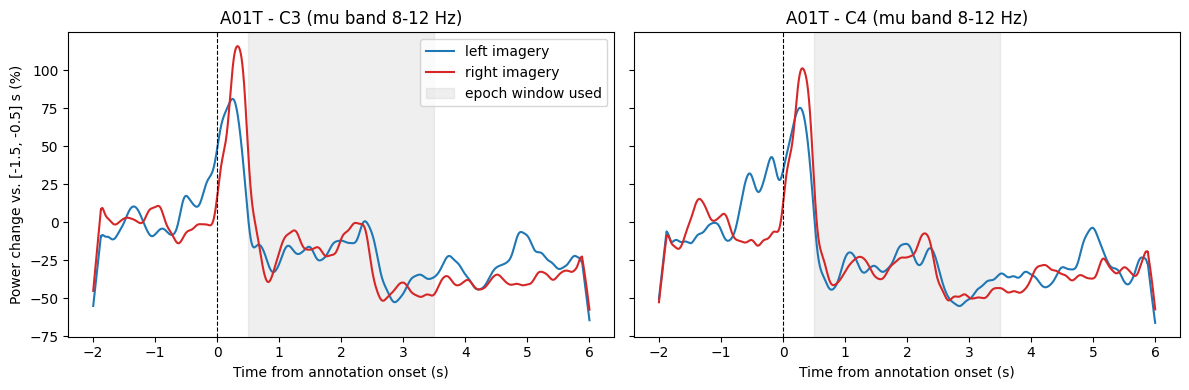

In [11]:
def erd_check(subject_id='A01T', band=(8., 12.), smooth_s=0.25):
    path = os.path.join(CLEAN_DATA_DIR, f'{subject_id}_clean_1_40_raw.fif')
    raw = mne.io.read_raw_fif(path, preload=True, verbose=False)
    raw.pick(['eeg']).filter(*band, verbose=False)
    events, _ = mne.events_from_annotations(raw, event_id=EVENT_ID, verbose=False)
    ep = mne.Epochs(raw, events, event_id={'left': 1, 'right': 2}, tmin=-2., tmax=6.,
                    baseline=None, preload=True, verbose=False)
    times = ep.times
    ref = (times >= -1.5) & (times <= -0.5)
    win = int(smooth_s * FS)
    kernel = np.ones(win) / win

    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
    for ax, ch in zip(axes, ['C3', 'C4']):
        for cls, color in [('left', 'tab:blue'), ('right', 'tab:red')]:
            d = ep[cls].copy().pick([ch]).get_data(copy=True)[:, 0, :]
            power = np.abs(hilbert(d, axis=-1)) ** 2
            p = power.mean(axis=0)
            p = np.convolve(p, kernel, mode='same')
            erd = 100 * (p - p[ref].mean()) / p[ref].mean()
            ax.plot(times, erd, color=color, label=f'{cls} imagery')
        ax.axvline(0, color='k', ls='--', lw=0.8)
        ax.axvspan(T_MIN, T_MAX, color='gray', alpha=0.12, label='epoch window used')
        ax.set_title(f'{subject_id} - {ch} (mu band {band[0]:.0f}-{band[1]:.0f} Hz)')
        ax.set_xlabel('Time from annotation onset (s)')
    axes[0].set_ylabel('Power change vs. [-1.5, -0.5] s (%)')
    axes[0].legend()
    plt.tight_layout()
    plt.show()

erd_check('A01T')

## Subject-wise split and Gaussian augmentation (training set only)

In [12]:
def add_gaussian_noise(X, std=NOISE_STD, seed=SEED):
    rng = np.random.default_rng(seed)
    return X + rng.normal(0, std, X.shape).astype(X.dtype)

def augment(X, y, std=NOISE_STD):
    """Original training trials + a noisy copy of them."""
    return np.concatenate([X, add_gaussian_noise(X, std)], axis=0), np.concatenate([y, y], axis=0)

def get_class_weights(y):
    classes = np.unique(y)
    w = class_weight.compute_class_weight('balanced', classes=classes, y=y)
    return {int(c): float(v) for c, v in zip(classes, w)}

X_train, y_train = stack(TRAIN_SUBJECTS)
X_val,   y_val   = stack(VAL_SUBJECTS)
X_test,  y_test  = stack(TEST_SUBJECTS)

X_train_aug, y_train_aug = augment(X_train, y_train)
class_weights_dict = get_class_weights(y_train_aug)

print(f'train: {X_train.shape[0]} trials ({TRAIN_SUBJECTS})  -> {X_train_aug.shape[0]} after augmentation')
print(f'val:   {X_val.shape[0]} trials ({VAL_SUBJECTS})')
print(f'test:  {X_test.shape[0]} trials ({TEST_SUBJECTS})')
print('class weights:', {k: round(v, 3) for k, v in class_weights_dict.items()})

train: 1440 trials (['A01T', 'A03T', 'A05T', 'A06T', 'A08T'])  -> 2880 after augmentation
val:   576 trials (['A04T', 'A07T'])
test:  576 trials (['A02T', 'A09T'])
class weights: {0: 1.0, 1: 1.0, 2: 1.0, 3: 1.0}


## EEGNet architecture

In [13]:
def EEGNet_Model(nb_classes, Chans=22, Samples=751, dropoutRate=0.5):
    """Standard EEGNet model for multiclass BCI decoding."""
    input1 = Input(shape=(Chans, Samples, 1))
    
    # Block 1: Temporal and Spatial Convolutions
    block1 = Conv2D(8, (1, 64), padding='same', use_bias=False)(input1)
    block1 = BatchNormalization()(block1)
    block1 = DepthwiseConv2D((Chans, 1), use_bias=False, depth_multiplier=2,
                              depthwise_constraint=max_norm(1.))(block1)
    block1 = BatchNormalization()(block1)
    block1 = Activation('elu')(block1)
    block1 = AveragePooling2D((1, 4))(block1)
    block1 = Dropout(dropoutRate)(block1)

    # Block 2: Separable Convolution
    block2 = SeparableConv2D(16, (1, 16), use_bias=False, padding='same')(block1)
    block2 = BatchNormalization()(block2)
    block2 = Activation('elu')(block2)
    block2 = AveragePooling2D((1, 8))(block2)
    block2 = Dropout(dropoutRate)(block2)

    flatten = Flatten()(block2)
    dense = Dense(nb_classes, kernel_constraint=max_norm(0.25))(flatten)
    softmax = Activation('softmax')(dense)
    
    return Model(inputs=input1, outputs=softmax)


def build_and_train(X_tr, y_tr, X_va, y_va, lr, dropout, batch_size, epochs, patience,
                    seed=SEED, verbose=0):
    """Train EEGNet with early stopping on the validation loss (best weights restored)."""
    tf.keras.backend.clear_session()
    set_seed(seed)
    model = EEGNet_Model(nb_classes=4, dropoutRate=dropout)
    model.compile(loss='sparse_categorical_crossentropy',
                  optimizer=Adam(learning_rate=lr), metrics=['accuracy'])
    callbacks = [tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=patience,
                                                  restore_best_weights=True)]
    history = model.fit(X_tr, y_tr, epochs=epochs, batch_size=int(batch_size),
                        validation_data=(X_va, y_va), class_weight=get_class_weights(y_tr),
                        callbacks=callbacks, verbose=verbose)
    val_acc = model.evaluate(X_va, y_va, verbose=0)[1]
    return model, history, val_acc

## Grid search (scored on the validation subjects only)

In [14]:
keys, values = zip(*PARAM_GRID.items())
combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]
search_results = []

print(f'Starting grid search: {len(combinations)} combinations, scored on validation subjects {VAL_SUBJECTS}')
for i, params in enumerate(combinations, 1):
    _, _, val_acc = build_and_train(X_train_aug, y_train_aug, X_val, y_val,
                                    lr=params['learning_rate'], dropout=params['dropout_rate'],
                                    batch_size=params['batch_size'],
                                    epochs=GRID_EPOCHS, patience=GRID_PATIENCE)
    search_results.append({**params, 'val_accuracy': val_acc})
    print(f'[{i}/{len(combinations)}] {params} -> val_acc={val_acc:.3f}')

results_df = pd.DataFrame(search_results).sort_values('val_accuracy', ascending=False).reset_index(drop=True)
print('\nGrid Search Rankings (validation subjects):')
print(results_df)

Starting grid search: 18 combinations, scored on validation subjects ['A04T', 'A07T']

[1/18] {'learning_rate': 0.001, 'dropout_rate': 0.4, 'batch_size': 16} -> val_acc=0.486
[2/18] {'learning_rate': 0.001, 'dropout_rate': 0.4, 'batch_size': 32} -> val_acc=0.493
[3/18] {'learning_rate': 0.001, 'dropout_rate': 0.5, 'batch_size': 16} -> val_acc=0.509
[4/18] {'learning_rate': 0.001, 'dropout_rate': 0.5, 'batch_size': 32} -> val_acc=0.530
[5/18] {'learning_rate': 0.001, 'dropout_rate': 0.6, 'batch_size': 16} -> val_acc=0.510
[6/18] {'learning_rate': 0.001, 'dropout_rate': 0.6, 'batch_size': 32} -> val_acc=0.514
[7/18] {'learning_rate': 0.0005, 'dropout_rate': 0.4, 'batch_size': 16} -> val_acc=0.483
[8/18] {'learning_rate': 0.0005, 'dropout_rate': 0.4, 'batch_size': 32} -> val_acc=0.497
[9/18] {'learning_rate': 0.0005, 'dropout_rate': 0.5, 'batch_size': 16} -> val_acc=0.514
[10/18] {'learning_rate': 0.0005, 'dropout_rate': 0.5, 'batch_size': 32} -> val_acc=0.502
[11/18] {'learning_rate': 0.

## Final training with visual history

Best configuration: LR=0.001, dropout=0.5, batch size=32
Epoch 1/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 20s 179ms/step - accuracy: 0.2986 - loss: 1.3717 - val_accuracy: 0.3194 - val_loss: 1.3771
Epoch 2/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 23s 204ms/step - accuracy: 0.4142 - loss: 1.2885 - val_accuracy: 0.3785 - val_loss: 1.3320
Epoch 3/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 21s 209ms/step - accuracy: 0.4542 - loss: 1.2242 - val_accuracy: 0.3767 - val_loss: 1.3153
Epoch 4/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 20s 202ms/step - accuracy: 0.4771 - loss: 1.2037 - val_accuracy: 0.3715 - val_loss: 1.3087
Epoch 5/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 18s 202ms/step - accuracy: 0.4962 - loss: 1.1863 - val_accuracy: 0.4271 - val_loss: 1.2871
Epoch 6/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 20s 200ms/step - accuracy: 0.5153 - loss: 1.1619 - val_accuracy: 0.4271 - val_loss: 1.2869
Epoch 7/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 21s 203ms/step - accuracy: 0.5191 - loss: 1.1447 - val_accuracy: 0.4358 - val_loss: 1.2830
Epoch 8/100
90/90 ━━━━━━━━━━━━━━━

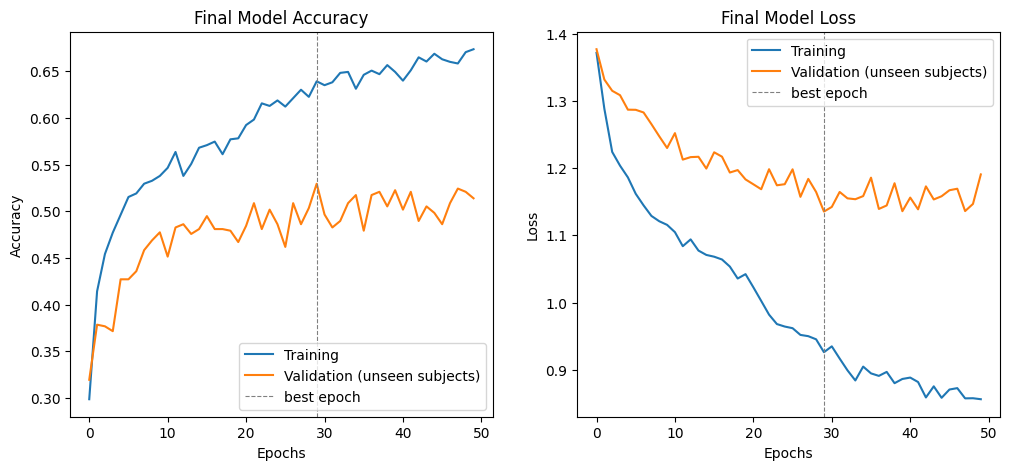

In [15]:
best_params = results_df.iloc[0]
print(f"Best configuration: LR={best_params['learning_rate']}, dropout={best_params['dropout_rate']}, "
      f"batch size={int(best_params['batch_size'])}")

final_model, history, final_val_acc = build_and_train(
    X_train_aug, y_train_aug, X_val, y_val,
    lr=best_params['learning_rate'], dropout=best_params['dropout_rate'],
    batch_size=best_params['batch_size'], epochs=FINAL_EPOCHS, patience=FINAL_PATIENCE, verbose=1)

best_epoch = int(np.argmin(history.history['val_loss']))
print(f'\nBest epoch (lowest val loss): {best_epoch + 1}  |  validation accuracy of restored weights: {final_val_acc:.3f}')

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training')
plt.plot(history.history['val_accuracy'], label='Validation (unseen subjects)')
plt.axvline(best_epoch, color='gray', ls='--', lw=0.8, label='best epoch')
plt.title('Final Model Accuracy'); plt.xlabel('Epochs'); plt.ylabel('Accuracy'); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training')
plt.plot(history.history['val_loss'], label='Validation (unseen subjects)')
plt.axvline(best_epoch, color='gray', ls='--', lw=0.8, label='best epoch')
plt.title('Final Model Loss'); plt.xlabel('Epochs'); plt.ylabel('Loss'); plt.legend()
plt.show()

## Final evaluation on the held-out test subjects 

Test subjects: ['A02T', 'A09T']  (576 trials)  |  chance level = 25%
Test accuracy: 0.470

Final Classification Report:
              precision    recall  f1-score   support

   Left Hand       0.57      0.30      0.39       144
  Right Hand       0.44      0.58      0.50       144
        Foot       0.37      0.54      0.44       144
      Tongue       0.65      0.46      0.54       144

    accuracy                           0.47       576
   macro avg       0.51      0.47      0.47       576
weighted avg       0.51      0.47      0.47       576



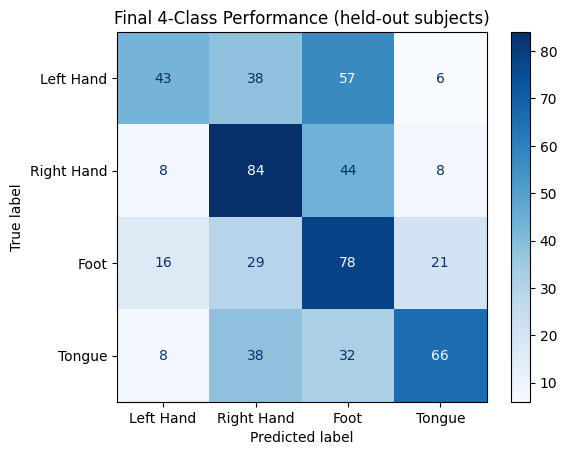

Accuracy per test subject:
  A02T: 0.382
  A09T: 0.559

Model exported successfully as final_eegnet_bci_model.keras


In [16]:
y_pred = np.argmax(final_model.predict(X_test, verbose=0), axis=1)
test_acc = float(np.mean(y_pred == y_test))

print(f'Test subjects: {TEST_SUBJECTS}  ({len(y_test)} trials)  |  chance level = 25%')
print(f'Test accuracy: {test_acc:.3f}\n')
print('Final Classification Report:')
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES).plot(cmap='Blues', values_format='d')
plt.title('Final 4-Class Performance (held-out subjects)')
plt.show()

print('Accuracy per test subject:')
for s in TEST_SUBJECTS:
    print(f'  {s}: {final_model.evaluate(*data[s], verbose=0)[1]:.3f}')

final_model.save('final_eegnet_bci_model.keras')
print('\nModel exported successfully as final_eegnet_bci_model.keras')

## Ablation: what do augmentation and bandwidth actually change?
Claims such as "Gaussian augmentation improves generalization" or "1-40 Hz is better than 8-30 Hz" are tested here, on the **validation** subjects (never on the test subjects), with the best hyper-parameters and several seeds. 

In [17]:
if RUN_ABLATION:
    data_8_30 = {s: load_subject(s, band=(8., 30.)) for s in ALL_SUBJECTS}

    def run_condition(name, store, use_aug):
        X_tr, y_tr = stack(TRAIN_SUBJECTS, store)
        X_va, y_va = stack(VAL_SUBJECTS, store)
        if use_aug:
            X_tr, y_tr = augment(X_tr, y_tr)
        accs = []
        for seed in ABLATION_SEEDS:
            _, _, acc = build_and_train(X_tr, y_tr, X_va, y_va,
                                        lr=best_params['learning_rate'], dropout=best_params['dropout_rate'],
                                        batch_size=best_params['batch_size'],
                                        epochs=ABL_EPOCHS, patience=ABL_PATIENCE, seed=seed)
            accs.append(acc)
            print(f'  {name} | seed {seed}: val_acc={acc:.3f}')
        return {'condition': name, 'val_acc_mean': np.mean(accs), 'val_acc_std': np.std(accs), 'n_seeds': len(accs)}

    ablation_df = pd.DataFrame([
        run_condition('1-40 Hz, no augmentation', data, False),
        run_condition('1-40 Hz + Gaussian noise', data, True),
        run_condition('8-30 Hz, no augmentation', data_8_30, False),
    ])
    print('\nAblation (validation subjects):')
    print(ablation_df.round(3).to_string(index=False))
else:
    print('RUN_ABLATION=False: skipped.')

  1-40 Hz, no augmentation | seed 0: val_acc=0.566
  1-40 Hz, no augmentation | seed 1: val_acc=0.514
  1-40 Hz, no augmentation | seed 2: val_acc=0.512
  1-40 Hz + Gaussian noise | seed 0: val_acc=0.557
  1-40 Hz + Gaussian noise | seed 1: val_acc=0.543
  1-40 Hz + Gaussian noise | seed 2: val_acc=0.502
  8-30 Hz, no augmentation | seed 0: val_acc=0.347
  8-30 Hz, no augmentation | seed 1: val_acc=0.335
  8-30 Hz, no augmentation | seed 2: val_acc=0.368

Ablation (validation subjects):
               condition  val_acc_mean  val_acc_std  n_seeds
1-40 Hz, no augmentation         0.531        0.025        3
1-40 Hz + Gaussian noise         0.534        0.024        3
8-30 Hz, no augmentation         0.350        0.014        3


## Leave-one-subject-out (LOSO) evaluation
Each subject is held out in turn as test set; the next subject (cyclically) is used as validation set for early stopping and the remaining seven for training. The hyper-parameters come from the grid search above, which used `VAL_SUBJECTS` for scoring, so the LOSO figures are only mildly optimistic for those two subjects. Set `RUN_LOSO = True` in the configuration cell to run it.

In [18]:
if RUN_LOSO:
    loso_rows = []
    for i, test_sub in enumerate(ALL_SUBJECTS):
        val_sub = ALL_SUBJECTS[(i + 1) % len(ALL_SUBJECTS)]
        train_subs = [s for s in ALL_SUBJECTS if s not in (test_sub, val_sub)]
        X_tr, y_tr = augment(*stack(train_subs))
        X_va, y_va = stack([val_sub])
        X_te, y_te = stack([test_sub])
        model, _, _ = build_and_train(X_tr, y_tr, X_va, y_va,
                                      lr=best_params['learning_rate'], dropout=best_params['dropout_rate'],
                                      batch_size=best_params['batch_size'],
                                      epochs=LOSO_EPOCHS, patience=LOSO_PATIENCE)
        acc = model.evaluate(X_te, y_te, verbose=0)[1]
        loso_rows.append({'test_subject': test_sub, 'val_subject': val_sub, 'test_acc': acc})
        print(f'{test_sub}: test_acc={acc:.3f}')
    loso_df = pd.DataFrame(loso_rows)
    print(f"\nLOSO mean accuracy: {loso_df['test_acc'].mean():.3f} +/- {loso_df['test_acc'].std(ddof=0):.3f}")
    print(loso_df.round(3).to_string(index=False))
else:
    print('RUN_LOSO=False: skipped.')

RUN_LOSO=False: skipped.


## 6. Results and discussion

### Performance overview
EEGNet was trained on subjects `TRAIN_SUBJECTS`, tuned on `VAL_SUBJECTS` and evaluated once on the unseen subjects `TEST_SUBJECTS`: **test accuracy = 47.0%** (chance level for 4 balanced classes = 25%). 
As expected in cross-subject BCI decoding, there is high inter-subject variability: Subject A09T reached an accuracy of 55.9%, while Subject A02T stopped at 38.2%. While lower than intra-subject or data-leaked models, this 47% represents a rigorous, realistic subject-independent baseline, proving the model is extracting genuine neurophysiological patterns rather than overfitting to stochastic session noise.

### Class-specific analysis
Based on the classification report, **Tongue** imagery is the best-separated class (F1-score = 0.54), driven by a high precision of 0.65. This aligns with physiological expectations, as the tongue's cortical representation is lateral and highly distinct from the limbs. **Right Hand** also performed reasonably well (F1-score = 0.50) with the highest recall (0.58). Conversely, **Left Hand** was the hardest class to decode (F1-score = 0.39), suffering from a very low recall (0.30), meaning it was frequently misclassified as other motor tasks. The low precision for **Foot** (0.37) indicates that other classes were often wrongly predicted as foot movement, reflecting the classic BCI challenge of resolving the central medial areas of the motor homunculus.

### Effect of the design choices
The ablation study on the validation subjects reveals that the frequency band selection was the most critical factor. The wide-band **1-40 Hz** approach (mean val_acc = 0.531) drastically outperformed the narrower **8-30 Hz** band (mean val_acc = 0.350). This gap of 18 percentage points is highly significant and well beyond the seed-to-seed standard deviation (0.014 - 0.025). 
Conversely, **Gaussian noise augmentation** (mean val_acc = 0.534) provided only a marginal +0.3% improvement over the unaugmented 1-40 Hz baseline. Since this difference is completely absorbed by the random seed standard deviation (0.024), we can conclude that for this specific architecture and dataset, the performance gain is entirely attributable to the wider frequency band rather than data augmentation.

### Limitations
* Single fixed split of subjects (two test subjects); the figure depends on which subjects are held out.
* Hyper-parameters tuned on only two validation subjects.
* The trial-to-event timing assumption was checked with the ERD plot above; if the plot contradicts it, the window must be revised before drawing any conclusion.

## Future work
1. **Subject-specific adaptation (Transfer Learning):** The 47% cross-subject baseline highlights the high inter-subject variability of EEG data. Fine-tuning the pooled model on a small calibration dataset from the target user (few-shot learning) is the most direct path to reaching clinical-grade accuracies (>70%).
2. **Riemannian geometry:** Incorporating Riemannian-manifold features to handle the non-stationarity of EEG across sessions and subjects, explicitly mapping the covariance matrices of the signals.
3. **Hybrid architectures:** Combining EEGNet with Transformer layers (attention mechanisms) to capture long-range temporal dependencies and better isolate the onset and offset of the ERD signatures.